# Phase 3 — Statistical Screening (diagnostics)

> **What this is.** A *filter*-type feature diagnostic between data cleaning (P1/P2) and modeling (P4).
> It does **not** change the data and does **not** train a model.
>
> **This notebook only visualizes** — all logic lives in `2_data/scripts/statistical_screening.py`.
> Three standard checks:
> 1. **Near-zero variance** — is any predictor almost constant?
> 2. **Predictor–predictor correlation** — redundancy.
> 3. **VIF** — multicollinearity (multivariate version of 2).
>
> Plus a descriptive predictor–target association view. Correlation figures reuse the leakage-safe
> train+validation outputs already produced by `run_modeling.py`; VIF and near-zero variance are
> computed by the screening script.

In [1]:
# ----- Project root + make the screening script importable -----
import sys, os
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "2_data" / "scripts" / "statistical_screening.py").exists():
            return c
    raise FileNotFoundError(f"Could not locate project root from {start}")

ROOT = _find_project_root(Path(os.getcwd()).resolve())
SCREENING_SCRIPTS = ROOT / "2_data" / "scripts"
if str(SCREENING_SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCREENING_SCRIPTS))
print("Project root:", ROOT)

Project root: /Users/jiesong/Documents/GitHub/env-innovation-prediction


In [2]:
# ----- Call the screening script (all logic lives there) -----
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import statistical_screening as ss

res = ss.run_screening()               # computes NZV + VIF, loads correlation outputs
nzv = res["near_zero_variance"]
vif = res["vif"]
corr = res["correlations"]
print("Panels screened:", list(res["panels"]),
      "| predictors:", {k: len(v[1]) for k, v in res["panels"].items()})

Panels screened: ['main', 'suba', 'subb', 'subc'] | predictors: {'main': 8, 'suba': 3, 'subb': 5, 'subc': 1}


## 1. Near-zero variance

> Almost-constant predictors carry no information and would be dropped.

In [3]:
display(nzv.round(4))
flagged = list(nzv.query("near_zero_variance")["feature"])
print("Near-zero-variance predictors:", flagged if flagged else "NONE -> nothing to drop ✅")

,panel_id,feature,n_obs,n_unique,std,coef_of_variation,dominant_value_share,near_zero_variance
0,main,renewable_energy_share,2510,1463,2.365460e+01,1.022200e+00,0.0255,False
1,main,wgi_regulatory_quality,2061,2061,9.656000e-01,2.864500e+00,0.0005,False
2,main,co2_per_capita_ar5,2571,2571,6.291800e+00,1.001700e+00,0.0004,False
3,main,fdi_net_inflows,2540,2539,4.395930e+10,2.752700e+00,0.0008,False
4,main,env_technology_rta,1940,1939,5.292000e-01,4.565000e-01,0.0010,False
5,main,trade_openness,2564,2564,5.899380e+01,6.621000e-01,0.0004,False
6,main,inflation,2439,2439,1.778350e+01,2.859200e+00,0.0004,False
7,main,size_factor,2552,2552,1.400700e+00,2.515440e+17,0.0004,False
8,suba,rise_energy_efficiency,1031,895,2.457340e+01,6.135000e-01,0.0184,False
9,suba,rise_renewable_energy,1031,831,2.132770e+01,7.220000e-01,0.0320,False


Near-zero-variance predictors: NONE -> nothing to drop ✅


## 2. Predictor–predictor correlation (main model)

> High |r| clusters make individual importances unstable. Reused from `run_modeling.py` (leakage-safe train+validation).

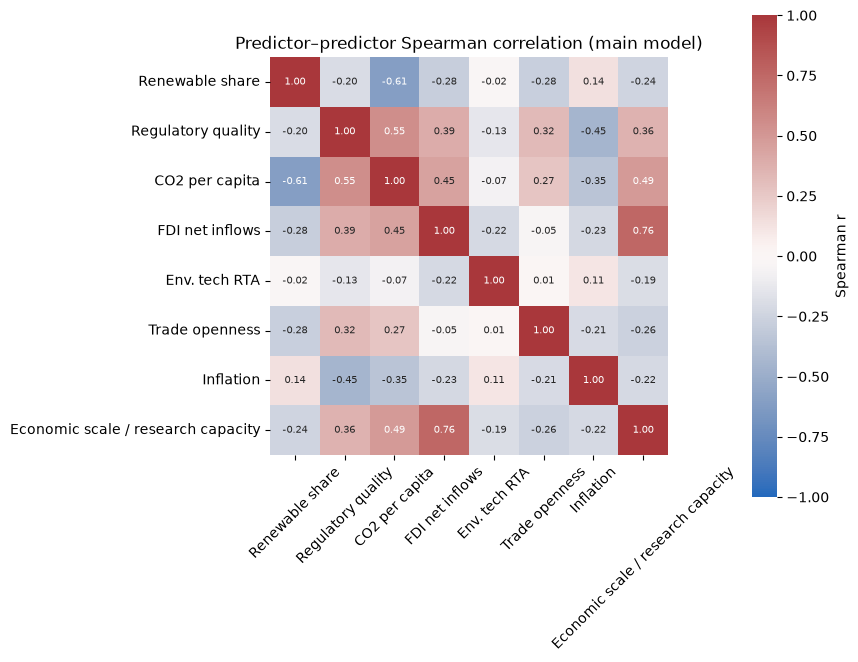

Most correlated predictor pairs:


,feature_a,feature_b,correlation
0,fdi_net_inflows_lag1_3_mean,size_factor_lag1_3_mean,0.757800
1,renewable_energy_share_lag1_3_mean,co2_per_capita_ar5_lag1_3_mean,-0.605711
2,wgi_regulatory_quality_lag1_3_mean,co2_per_capita_ar5_lag1_3_mean,0.548990
3,co2_per_capita_ar5_lag1_3_mean,size_factor_lag1_3_mean,0.488150
4,wgi_regulatory_quality_lag1_3_mean,inflation_lag1_3_mean,-0.452890
5,co2_per_capita_ar5_lag1_3_mean,fdi_net_inflows_lag1_3_mean,0.451581


In [4]:
if corr["spearman_matrix"] is not None:
    fig = ss.figure_correlation_heatmap(corr["spearman_matrix"]); display(fig); plt.close(fig)
    print("Most correlated predictor pairs:")
    display(corr["top_pairs"].head(6)[["feature_a", "feature_b", "correlation"]])
else:
    print("Correlation outputs not found. Run: python 3_models/scripts/run_modeling.py")

## 3. VIF (multicollinearity)

> Rule of thumb: VIF > 5 moderate, > 10 severe. Computed by the screening script on median-imputed, standardized features (no target).

,panel_id,feature,vif,flag
0,main,size_factor,2.600,ok
1,main,fdi_net_inflows,2.489,ok
2,main,wgi_regulatory_quality,1.438,ok
3,main,co2_per_capita_ar5,1.430,ok
4,main,trade_openness,1.392,ok
5,main,renewable_energy_share,1.321,ok
6,main,env_technology_rta,1.050,ok
7,main,inflation,1.034,ok
8,suba,rise_energy_efficiency,3.407,ok
9,suba,rise_renewable_energy,3.108,ok


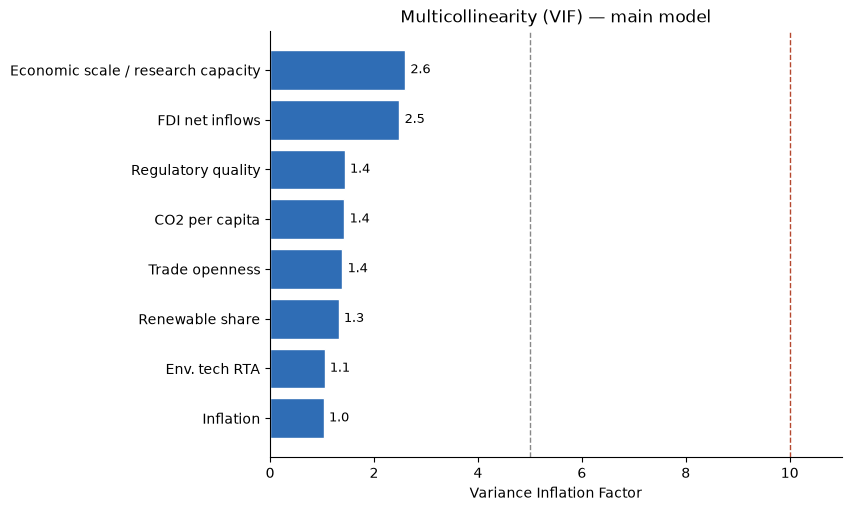

severe (VIF>=10): NONE
moderate (5<=VIF<10): NONE


In [5]:
display(vif)
fig = ss.figure_vif(vif, "main"); display(fig); plt.close(fig)
print("severe (VIF>=10):", list(vif.query("flag=='severe'")["feature"]) or "NONE")
print("moderate (5<=VIF<10):", list(vif.query("flag=='moderate'")["feature"]) or "NONE")

## 4. Predictor–target association (descriptive)

> Leakage-safe train+validation correlations. Shown for context only — **not** used to drop predictors.

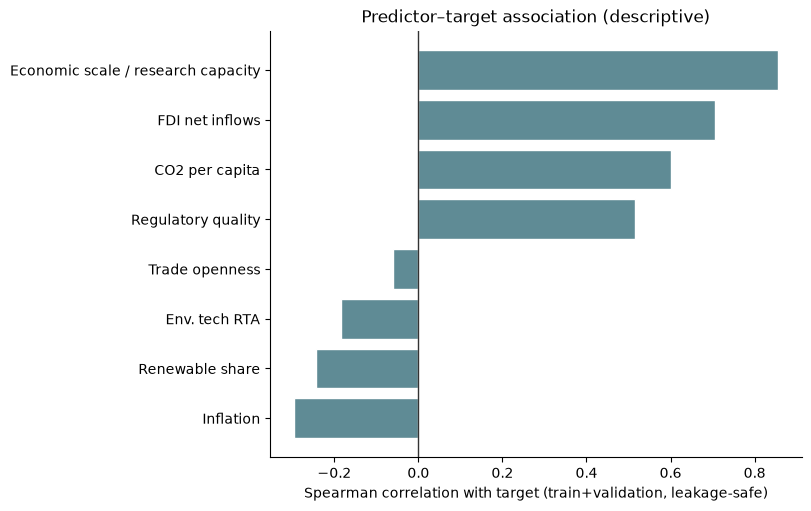

In [6]:
if corr["target_correlations"] is not None:
    fig = ss.figure_target_correlations(corr["target_correlations"]); display(fig); plt.close(fig)
else:
    print("Run: python 3_models/scripts/run_modeling.py to generate target correlations")

## 5. Conclusion — what P3 decides

- **Near-zero variance:** none → nothing to drop.
- **Correlation / VIF:** only **GDP (VIF≈14)** and **scientific output (VIF≈13)** are high — they jointly proxy *economic size / research capacity* (Spearman r≈0.88). Everything else < 2.5; SubA/B/C all fine.
- **Decision:** keep all predictors. Dropping one of GDP/scientific would discard jointly-informative signal (permutation importance shows scientific output is actually the strongest predictor). The collinearity is handled by the **model layer**: ElasticNet (L2 grouping) + permutation importance.
- **Funnel:** `after P2: 18 → P3 (diagnostic, still 18) → P4 (ElasticNet embedded selection)`. **No predictors removed, no models re-run.**